In [31]:
# import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [17]:
# remove warnings
import warnings
warnings.filterwarnings('ignore')

# load the dataset
titanic = sns.load_dataset("titanic")

# drop the rows with missing values from the dataset
titanic.dropna(subset=['age', 'embarked'], inplace=True)

# impute the missing values in the dataset with the help of pandas get_dummies function
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)
X = titanic.drop(["survived", 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
y = titanic['survived']

X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size=0.2, random_state=42)

In [26]:
# Define the layers of the model 
input_layer = tf.keras.layers.Dense(10, activation = 'relu', input_shape=(X_train.shape[1],))
output_layer = tf.keras.layers.Dense(1, activation ='sigmoid')

# Compbine the layers into the model 
model = tf.keras.models.Sequential([input_layer,  output_layer])

# compile the model 

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [27]:
%%time
# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4780 - loss: 6.3442
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4552 - loss: 5.3979
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4710 - loss: 4.4275
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4921 - loss: 3.4584
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5185 - loss: 2.4981
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5571 - loss: 1.5371
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6344 - loss: 0.8352
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7504 - loss: 0.5065
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7540 - loss: 0.4969
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7645 - loss: 0.4919
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7540 - loss: 0.4871
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

## **Let's see all the steps in action within one snippet of code**

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7692 - loss: 0.4909 
Test Accuracy: 0.7692307829856873
Test Loss: 0.49088427424430847


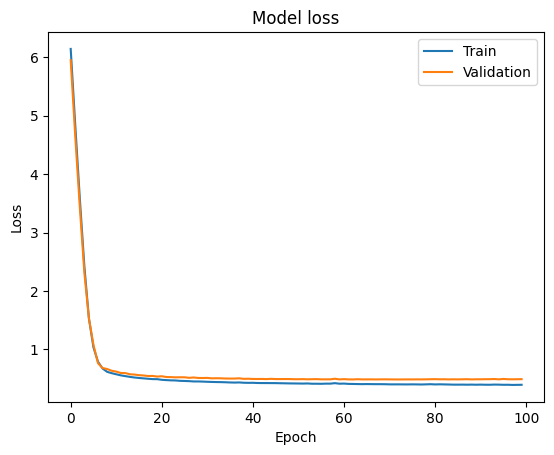

CPU times: total: 1min 20s
Wall time: 2min 3s


In [ ]:
%%time
import warnings
warnings.filterwarnings('ignore')

def simple_neural_networks(pass_dataset):
    dataset = pass_dataset.dropna(subset=['age', 'embarked'])  # no inplace, so it's reassigned
    dataset = pd.get_dummies(dataset, columns=['embarked', 'sex', 'who', 'class', 'deck'])
    
    X = dataset.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
    y = dataset['survived']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    input_layer = tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],))
    output_layer = tf.keras.layers.Dense(1, activation='sigmoid')  # sigmoid for binary classification
    model = tf.keras.models.Sequential([input_layer, output_layer])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_data=(X_test, y_test))
    loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
    # Evluating the model
    print(f"Test Accuracy: {accuracy}")
    print(f"Test Loss: {loss}")

    # Plot the Training and Validation Accuracy and Loss for each epoch
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()
    
    return model, X_test, y_test  # return what you actually need

titanic = sns.load_dataset('titanic')
model, X_test, y_test = simple_neural_networks(titanic)

## **Let's plot each epoch and validation**

In [8]:
import sys

import tensorflow.keras
import pandas as pd
import sklearn as sk
import scipy as sp
import tensorflow as tf
import platform

print(f"Python Platform: {platform.platform()}")
print(f"Tensor Flow Version: {tf.__version__}")
print()
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Scikit-Learn {sk.__version__}")
print(f"SciPy {sp.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

Python Platform: Windows-10-10.0.19045-SP0
Tensor Flow Version: 2.21.0

Python 3.10.21 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:35:39) [MSC v.1942 64 bit (AMD64)]
Pandas 2.3.3
Scikit-Learn 1.7.2
SciPy 1.15.3
GPU is NOT AVAILABLE
